# 05. Optuna 계수 튜닝 결과 분석

Phase 2-A.5 Bayesian 최적화 (50 trials) 결과를 심층 분석한다.

**결과 요약**
- 베이스라인(exp013b): Val Sharpe = 17.579
- 최적 Trial #42: Val Sharpe = 42.997 (+145%)
- 탐색 계수: A_b, B_b, C_b, D_b (buy) + A_s, B_s, C_s, D_s (sell)

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import yaml
from scipy import stats

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

BASELINE  = 17.579   # exp013b
BEST_VAL  = 42.997   # Trial #42

# 데이터 로드
df_raw = pd.read_csv(ROOT / "experiments/optuna_coef_v1/all_trials.csv")
with open(ROOT / "experiments/optuna_coef_v1/best_coefs.yaml", encoding="utf-8") as f:
    best_cfg = yaml.safe_load(f)

# 유효 trial (제약 위반 -999 제외)
df = df_raw[df_raw["value"] > 0].copy().reset_index(drop=True)
coef_cols = [c for c in df.columns if c.startswith("params_")]
coef_labels = [c.replace("params_", "") for c in coef_cols]

print(f"전체 trials : {len(df_raw)}")
print(f"유효 trials : {len(df)}")
print(f"제약 위반   : {len(df_raw) - len(df)}")
print(f"\n최고 Sharpe : {df['value'].max():.3f} (Trial #{df['value'].idxmax()})")
print(f"중앙값      : {df['value'].median():.3f}")
print(f"베이스라인  : {BASELINE}")

전체 trials : 50
유효 trials : 48
제약 위반   : 2

최고 Sharpe : 42.997 (Trial #40)
중앙값      : 14.850
베이스라인  : 17.579


## 1. 전체 Trial Sharpe 분포

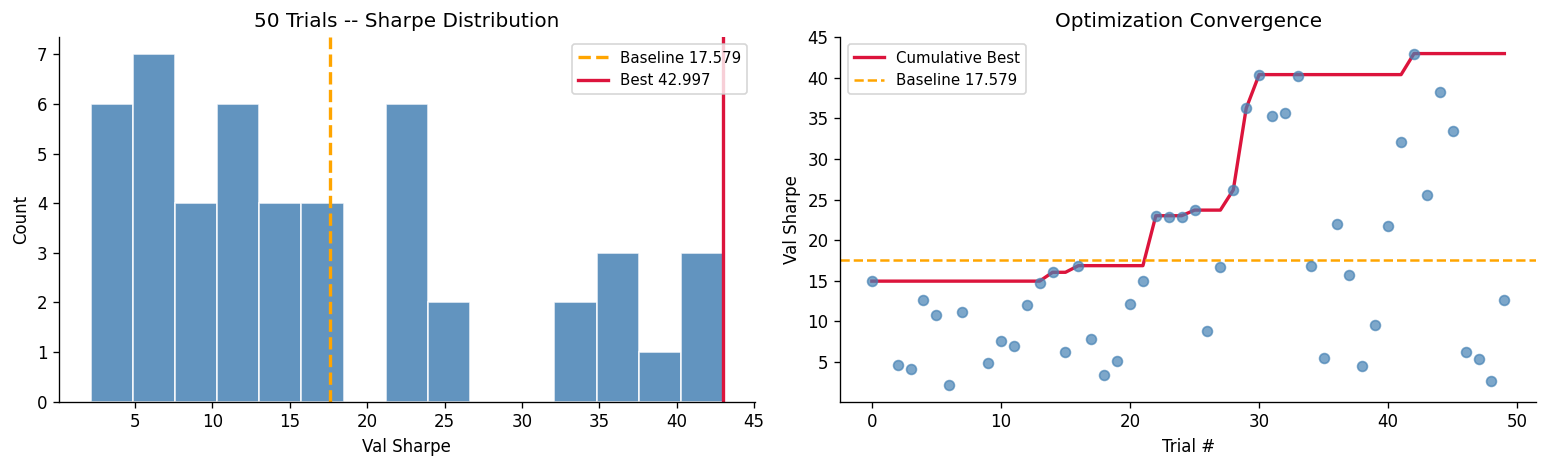

베이스라인 초과 trials: 17 / 48


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 히스토그램
ax = axes[0]
ax.hist(df["value"], bins=15, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(BASELINE, color="orange", lw=2, linestyle="--", label=f"Baseline {BASELINE}")
ax.axvline(BEST_VAL, color="crimson",  lw=2, linestyle="-",  label=f"Best {BEST_VAL}")
ax.set_xlabel("Val Sharpe")
ax.set_ylabel("Count")
ax.set_title("50 Trials -- Sharpe Distribution")
ax.legend(fontsize=9)

# 시간 순서별 Sharpe 수렴 플롯
ax2 = axes[1]
ax2.scatter(df["number"], df["value"], color="steelblue", s=35, alpha=0.7, zorder=3)
best_so_far = df["value"].cummax()
ax2.plot(df["number"], best_so_far, color="crimson", lw=2, label="Cumulative Best")
ax2.axhline(BASELINE, color="orange", lw=1.5, linestyle="--", label=f"Baseline {BASELINE}")
ax2.set_xlabel("Trial #")
ax2.set_ylabel("Val Sharpe")
ax2.set_title("Optimization Convergence")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_01_distribution.png", bbox_inches="tight")
plt.show()
print(f"베이스라인 초과 trials: {(df['value'] > BASELINE).sum()} / {len(df)}")

## 2. 계수별 Sharpe 산점도 (중요도 시각화)

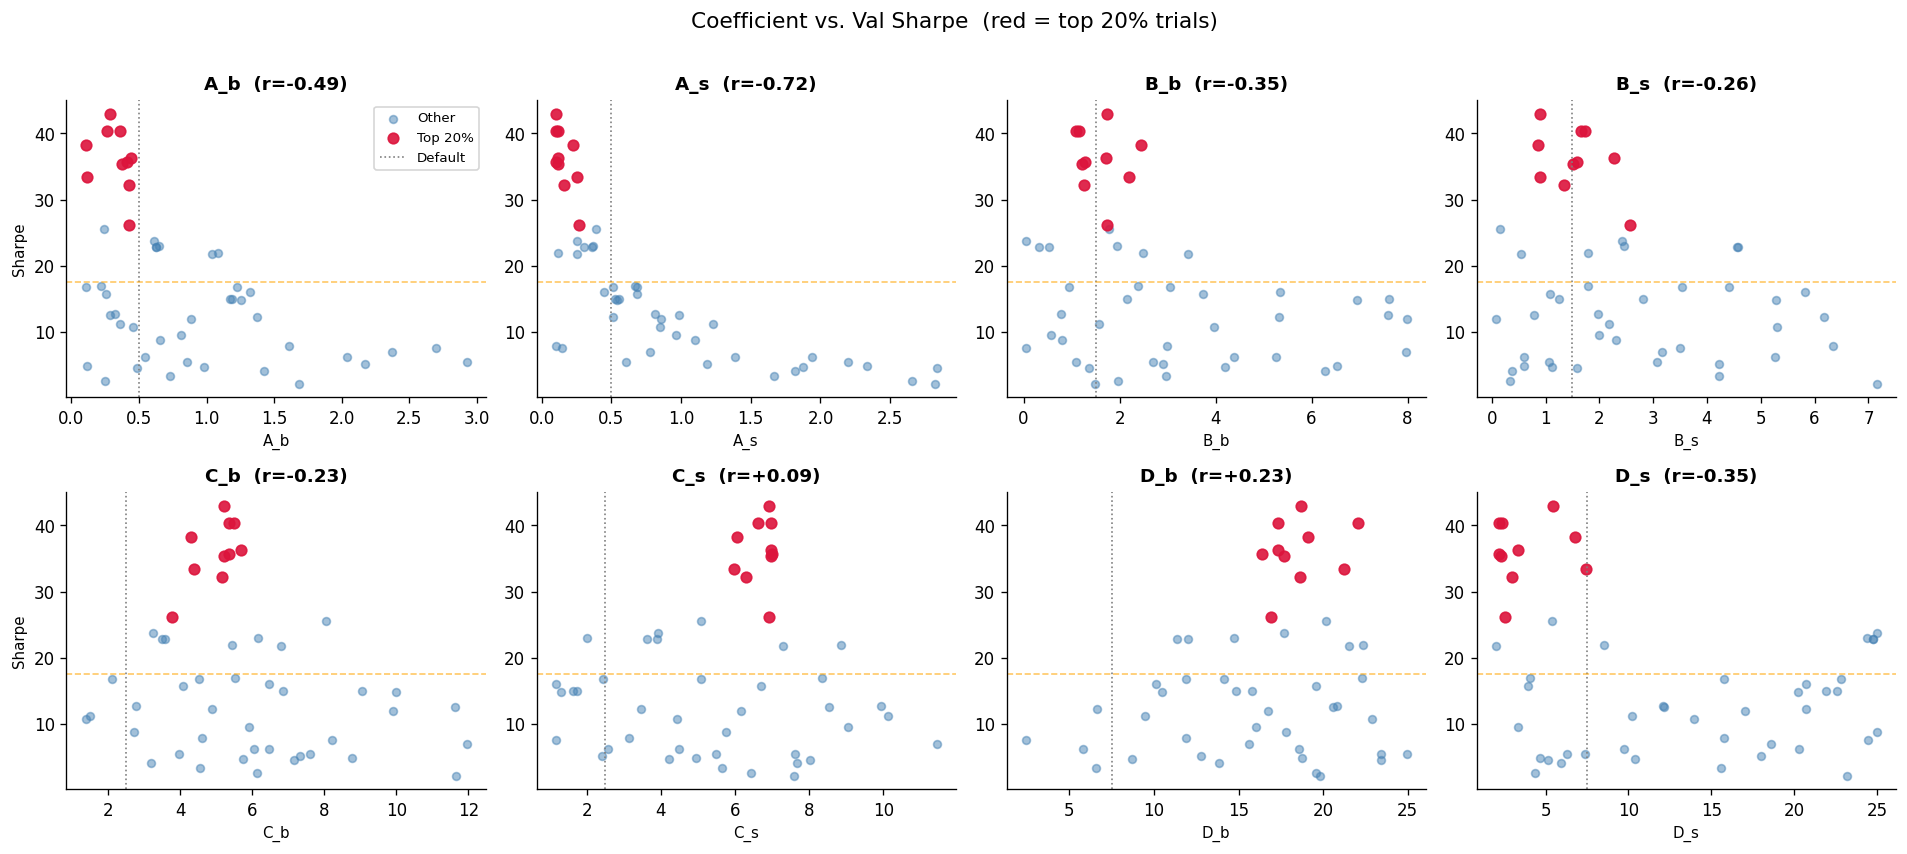

In [3]:
top10_mask = df["value"] >= df["value"].quantile(0.80)
default_vals = {"A_b": 0.5, "B_b": 1.5, "C_b": 2.5, "D_b": 7.5,
                "A_s": 0.5, "B_s": 1.5, "C_s": 2.5, "D_s": 7.5}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col, label in zip(axes, coef_cols, coef_labels):
    x_all = df.loc[~top10_mask, col]
    y_all = df.loc[~top10_mask, "value"]
    x_top = df.loc[top10_mask, col]
    y_top = df.loc[top10_mask, "value"]

    ax.scatter(x_all, y_all, s=22, alpha=0.5, color="steelblue", label="Other")
    ax.scatter(x_top, y_top, s=40, alpha=0.9, color="crimson",   label="Top 20%")

    # 기본값 수직선
    ax.axvline(default_vals[label], color="gray", lw=1, linestyle=":", label="Default")
    # 베이스라인 수평선
    ax.axhline(BASELINE, color="orange", lw=1, linestyle="--", alpha=0.6)

    r, p = stats.pearsonr(df[col], df["value"])
    ax.set_title(f"{label}  (r={r:+.2f})", fontsize=11, fontweight="bold")
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel("Sharpe" if ax in axes[::4] else "", fontsize=9)

axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("Coefficient vs. Val Sharpe  (red = top 20% trials)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_02_scatter.png", bbox_inches="tight")
plt.show()

## 3. 계수 중요도 (Pearson 상관계수)

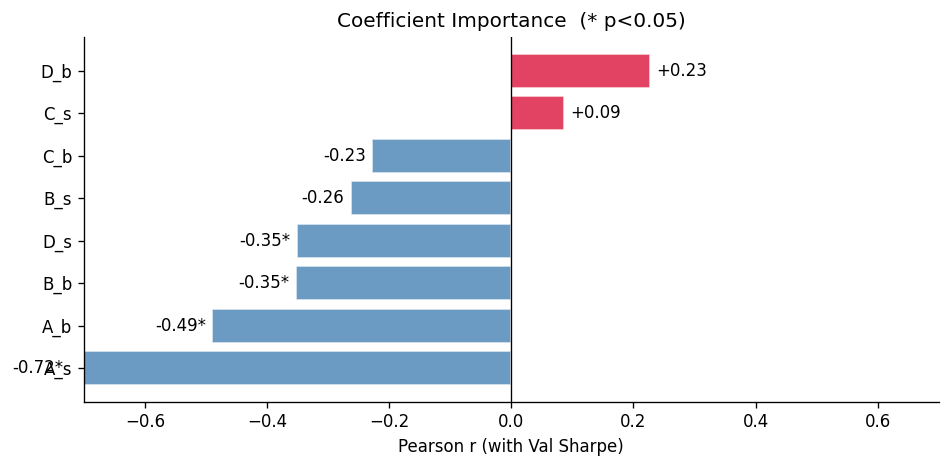


계수 중요도 순위 (|r| 기준):
            r         p significant
A_s  0.723915       0.0        True
A_b   0.48968  0.000412        True
B_b  0.353107  0.013825        True
D_s  0.351475  0.014301        True
B_s  0.263159  0.070738       False
C_b  0.228295  0.118602       False
D_b  0.227509   0.11991       False
C_s  0.086408  0.559244       False


In [4]:
corrs = {}
for col, label in zip(coef_cols, coef_labels):
    r, p = stats.pearsonr(df[col], df["value"])
    corrs[label] = {"r": r, "p": p, "significant": p < 0.05}

corr_df = pd.DataFrame(corrs).T.sort_values("r")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["crimson" if r > 0 else "steelblue" for r in corr_df["r"]]
bars = ax.barh(corr_df.index, corr_df["r"], color=colors, alpha=0.8, edgecolor="white")

for bar, (_, row) in zip(bars, corr_df.iterrows()):
    sig = "*" if row["significant"] else ""
    x = bar.get_width()
    ax.text(x + (0.01 if x >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"{x:+.2f}{sig}", va="center", ha="left" if x >= 0 else "right", fontsize=10)

ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r (with Val Sharpe)")
ax.set_title("Coefficient Importance  (* p<0.05)")
ax.set_xlim(-0.7, 0.7)

plt.tight_layout()
plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_03_importance.png", bbox_inches="tight")
plt.show()

print("\n계수 중요도 순위 (|r| 기준):")
print(corr_df[["r", "p", "significant"]].abs().sort_values("r", ascending=False).to_string())

## 4. 경계 분석: A_s 집중

C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s

C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\2477955450.py:34: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from

D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: Us

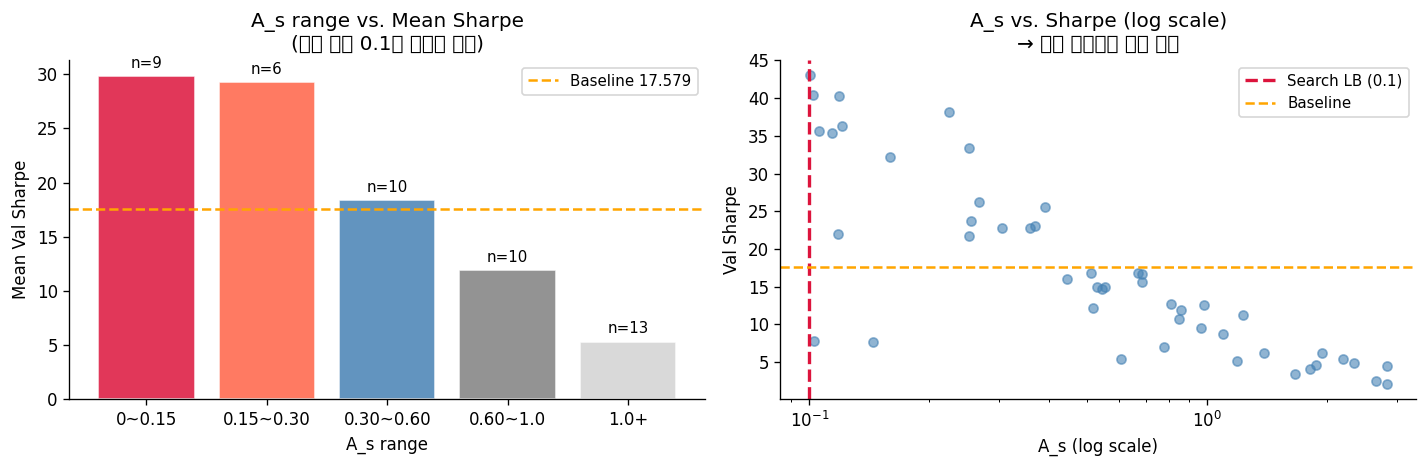


A_s 구간별 평균 Sharpe:
                mean     median  count
A_s_bin                               
0~0.15     29.817118  35.666165      9
0.15~0.30  29.239315  29.158564      6
0.30~0.60  18.391078  16.442329     10
0.60~1.0   11.920812  12.278244     10
1.0+        5.324235   4.853385     13

결론: A_s < 0.15 구간이 압도적으로 우세 → Round 2에서 [0.01, 0.15]로 범위 축소 권고


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# A_s 구간별 평균 Sharpe
bins   = [0, 0.15, 0.30, 0.60, 1.0, 3.1]
labels = ["0~0.15", "0.15~0.30", "0.30~0.60", "0.60~1.0", "1.0+"]
df["A_s_bin"] = pd.cut(df["params_A_s"], bins=bins, labels=labels)
bin_stats = df.groupby("A_s_bin", observed=True)["value"].agg(["mean", "median", "count"])

ax = axes[0]
bars = ax.bar(bin_stats.index, bin_stats["mean"],
              color=["crimson", "tomato", "steelblue", "gray", "lightgray"],
              edgecolor="white", alpha=0.85)
for bar, (_, row) in zip(bars, bin_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"n={int(row['count'])}", ha="center", va="bottom", fontsize=9)
ax.axhline(BASELINE, color="orange", lw=1.5, linestyle="--", label=f"Baseline {BASELINE}")
ax.set_xlabel("A_s range")
ax.set_ylabel("Mean Val Sharpe")
ax.set_title("A_s range vs. Mean Sharpe\n(탐색 하한 0.1에 최적값 집중)")
ax.legend(fontsize=9)

# A_s 전체 산점도 + 추세선
ax2 = axes[1]
ax2.scatter(df["params_A_s"], df["value"], s=30, alpha=0.6, color="steelblue")
# 로그 스케일 x축으로 트렌드 더 잘 보임
ax2.axvline(0.1, color="crimson", lw=2, linestyle="--", label="Search LB (0.1)")
ax2.axhline(BASELINE, color="orange", lw=1.5, linestyle="--", label=f"Baseline")
ax2.set_xscale("log")
ax2.set_xlabel("A_s (log scale)")
ax2.set_ylabel("Val Sharpe")
ax2.set_title("A_s vs. Sharpe (log scale)\n→ 하한 근방에서 성능 최고")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_04_As_boundary.png", bbox_inches="tight")
plt.show()

print("\nA_s 구간별 평균 Sharpe:")
print(bin_stats.to_string())
print(f"\n결론: A_s < 0.15 구간이 압도적으로 우세 → Round 2에서 [0.01, 0.15]로 범위 축소 권고")

## 5. Top-10 Trial 히트맵

C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:34: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:34: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:34: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:34: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:34: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:34: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) D

C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:35: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_05_top10_heatmap.png", bbox_inches="tight")
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:35: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_05_top10_heatmap.png", bbox_inches="tight")
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:35: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_05_top10_heatmap.png", bbox_inches="tight")
C:\Users\user\AppData\Local\Temp\ipykernel_26392\722983994.py:35: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_05_top10_heatmap.png", bbox_inches="tight")
C:\Users\

D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: Use

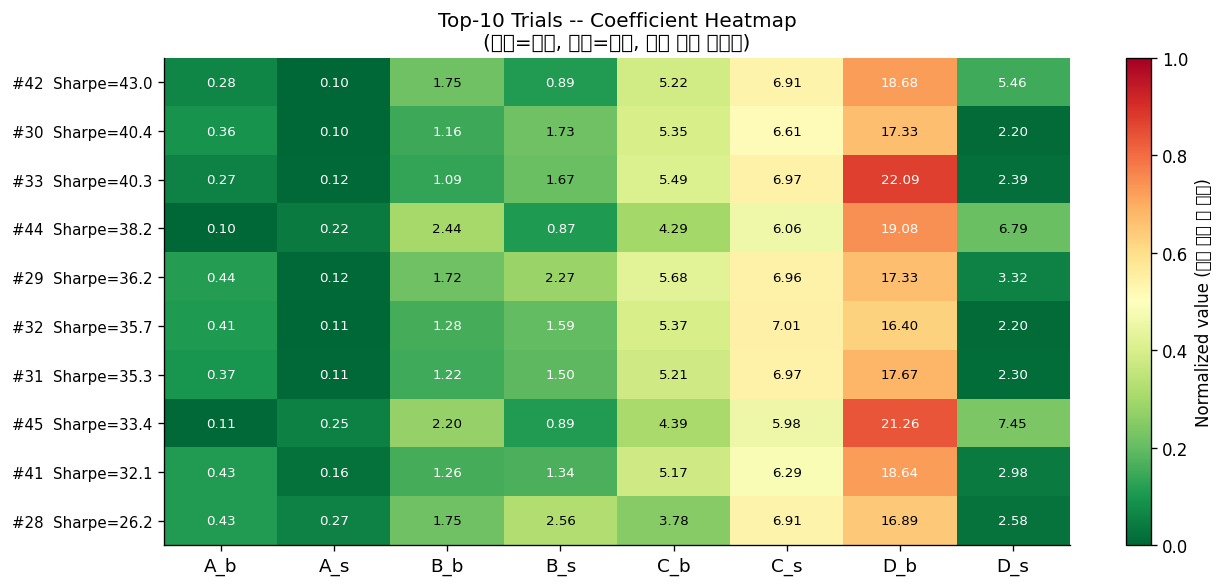

In [6]:
top10 = df.nlargest(10, "value")[["number", "value"] + coef_cols].copy()
top10.columns = ["Trial", "Sharpe"] + coef_labels
top10 = top10.set_index("Trial")

# 계수를 [0,1]로 정규화 (탐색 범위 기준)
search_space = {
    "A_b": (0.1, 3.0), "B_b": (0.0, 8.0), "C_b": (1.0, 12.0), "D_b": (2.0, 25.0),
    "A_s": (0.1, 3.0), "B_s": (0.0, 8.0), "C_s": (1.0, 12.0), "D_s": (2.0, 25.0),
}
norm = top10[coef_labels].copy()
for col, (lo, hi) in search_space.items():
    norm[col] = (norm[col] - lo) / (hi - lo)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(norm.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Normalized value (탐색 범위 내 위치)")

ax.set_xticks(range(len(coef_labels)))
ax.set_xticklabels(coef_labels, fontsize=11)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(
    [f"#{idx}  Sharpe={s:.1f}" for idx, s in zip(top10.index, top10["Sharpe"])],
    fontsize=9
)

# 셀 값 표시
for i, row in enumerate(norm.values):
    for j, val in enumerate(row):
        ax.text(j, i, f"{top10[coef_labels].iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if val > 0.7 or val < 0.2 else "black")

ax.set_title("Top-10 Trials -- Coefficient Heatmap\n(초록=낮음, 빨강=높음, 탐색 범위 정규화)")
plt.tight_layout()
plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_05_top10_heatmap.png", bbox_inches="tight")
plt.show()

## 6. 최적 계수 해석: Gap 범위 비교

C:\Users\user\AppData\Local\Temp\ipykernel_26392\729668334.py:55: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


최적 계수 gap 범위 비교
            Gap 기본값 범위 (×ATR) 최적값 범위 (×ATR)   변화
     buy_hi_gap  [0.50, 2.00]  [0.28, 2.03] ↑ 확장
     buy_lo_gap [2.50, 10.00] [5.22, 23.91] ↑ 확장
sell_market_gap  [0.50, 2.00]  [0.10, 0.99] ↓ 축소
  sell_cost_gap [2.50, 10.00] [6.91, 12.37] ↑ 확장


C:\Users\user\AppData\Local\Temp\ipykernel_26392\729668334.py:55: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\729668334.py:55: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\729668334.py:55: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\729668334.py:55: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\729668334.py:55: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_26392\729668334.py:55: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) 

D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\development\claude\capstone-rl-trading\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: 

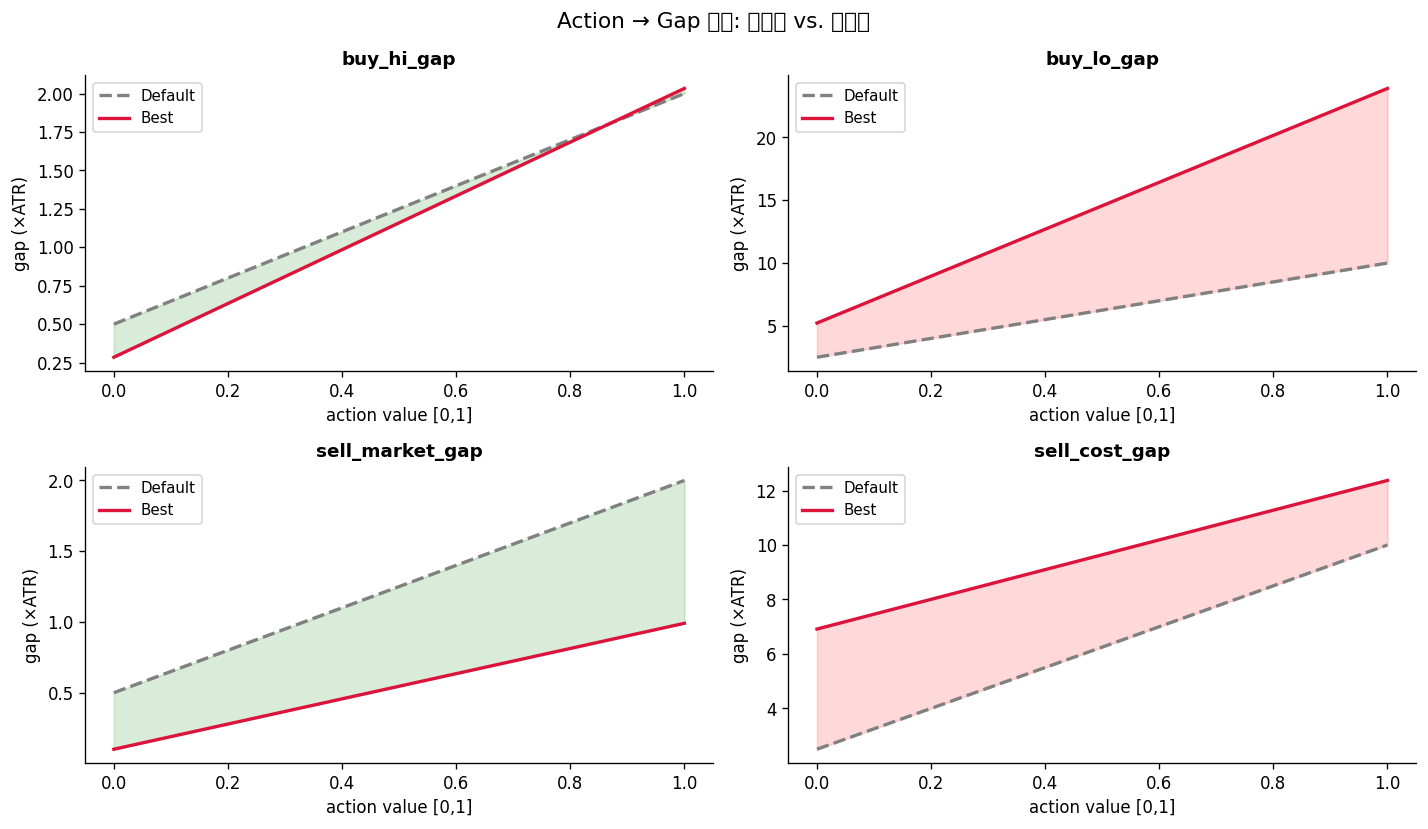

In [7]:
default_coefs = {"A_b": 0.5, "B_b": 1.5, "C_b": 2.5, "D_b": 7.5,
                 "A_s": 0.5, "B_s": 1.5, "C_s": 2.5, "D_s": 7.5}
best_coefs   = best_cfg["formula_coefs"]

agg = np.linspace(0, 1, 100)

def gap_range(A, B, agg_arr):
    gaps = A + B * agg_arr
    return gaps.min(), gaps.max()

rows = []
for name, A_key, B_key in [
    ("buy_hi_gap",      "A_b", "B_b"),
    ("buy_lo_gap",      "C_b", "D_b"),
    ("sell_market_gap", "A_s", "B_s"),
    ("sell_cost_gap",   "C_s", "D_s"),
]:
    d_lo, d_hi = gap_range(default_coefs[A_key], default_coefs[B_key], agg)
    b_lo, b_hi = gap_range(best_coefs[A_key],    best_coefs[B_key],    agg)
    rows.append({
        "Gap": name,
        "기본값 범위 (×ATR)": f"[{d_lo:.2f}, {d_hi:.2f}]",
        "최적값 범위 (×ATR)": f"[{b_lo:.2f}, {b_hi:.2f}]",
        "변화": "↓ 축소" if b_hi < d_hi and b_lo < d_lo else
                "↑ 확장" if b_hi > d_hi else "~ 유사",
        "b_lo": b_lo, "b_hi": b_hi,
    })

gap_df = pd.DataFrame(rows)
print("=" * 70)
print("최적 계수 gap 범위 비교")
print("=" * 70)
print(gap_df[["Gap", "기본값 범위 (×ATR)", "최적값 범위 (×ATR)", "변화"]].to_string(index=False))

# 시각화: action [0,1] 전 범위 gap 곡선
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (name, A_key, B_key) in zip(axes.flatten(), [
    ("buy_hi_gap",      "A_b", "B_b"),
    ("buy_lo_gap",      "C_b", "D_b"),
    ("sell_market_gap", "A_s", "B_s"),
    ("sell_cost_gap",   "C_s", "D_s"),
]):
    d_gaps = default_coefs[A_key] + default_coefs[B_key] * agg
    b_gaps = best_coefs[A_key]    + best_coefs[B_key]    * agg
    ax.plot(agg, d_gaps, "--", color="gray",    lw=2, label="Default")
    ax.plot(agg, b_gaps, "-",  color="crimson", lw=2, label="Best")
    ax.fill_between(agg, b_gaps, d_gaps, alpha=0.15,
                    color="green" if (b_gaps < d_gaps).mean() > 0.5 else "red")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("action value [0,1]")
    ax.set_ylabel("gap (×ATR)")
    ax.legend(fontsize=9)

fig.suptitle("Action → Gap 변환: 기본값 vs. 최적값", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "experiments/optuna_coef_v1/fig_06_gap_comparison.png", bbox_inches="tight")
plt.show()

## 7. 경제적 해석 및 전략 요약

In [8]:
print("=" * 65)
print("최적 계수 경제적 해석")
print("=" * 65)
print("""
[매수 전략 변화]
  buy_hi_gap : [0.5, 2.0]→[0.28, 2.03]×ATR  — 기저 축소
    → 현재가보다 조금만 내려가도 buy_hi 체결 (더 공격적 진입)
  buy_lo_gap : [2.5, 10.0]→[5.22, 23.9]×ATR  — 대폭 확장
    → buy_lo가 훨씬 낮은 가격 (큰 조정 때 저점 적극 포착)

[매도 전략 변화]
  sell_market_gap: [0.5, 2.0]→[0.10, 1.0]×ATR  — 대폭 축소
    → 가격이 조금만 올라도 즉시 매도 (현금 회수 극대화)
  sell_cost_gap:   [2.5, 10.0]→[6.9, 12.4]×ATR  — 상향 고정
    → sell_cost는 높은 기준 (6.9×ATR 이상 랠리 때만 평단가 기준 매도)

[전략 요약]
  - 매수: 현재가 근처에서 빠르게 + buy_lo로 저점 저가 매수 대기
  - 매도: sell_market으로 소폭 상승마다 즉시 현금화 (단타 중심)
          sell_cost는 큰 랠리 전용 (홀딩 유지 조건 강화)
  - 결과: 매우 빈번한 소수익 사이클 + 가끔 대형 수익 사이클 혼합
""")

print("=" * 65)
print("최적 계수값 (exp016 config 적용 예정)")
print("=" * 65)
for k, v in best_coefs.items():
    default = default_coefs[k]
    pct = (v - default) / default * 100
    print(f"  {k}: {v:.4f}  (기본값 {default} → {pct:+.0f}%)")

최적 계수 경제적 해석

[매수 전략 변화]
  buy_hi_gap : [0.5, 2.0]→[0.28, 2.03]×ATR  — 기저 축소
    → 현재가보다 조금만 내려가도 buy_hi 체결 (더 공격적 진입)
  buy_lo_gap : [2.5, 10.0]→[5.22, 23.9]×ATR  — 대폭 확장
    → buy_lo가 훨씬 낮은 가격 (큰 조정 때 저점 적극 포착)

[매도 전략 변화]
  sell_market_gap: [0.5, 2.0]→[0.10, 1.0]×ATR  — 대폭 축소
    → 가격이 조금만 올라도 즉시 매도 (현금 회수 극대화)
  sell_cost_gap:   [2.5, 10.0]→[6.9, 12.4]×ATR  — 상향 고정
    → sell_cost는 높은 기준 (6.9×ATR 이상 랠리 때만 평단가 기준 매도)

[전략 요약]
  - 매수: 현재가 근처에서 빠르게 + buy_lo로 저점 저가 매수 대기
  - 매도: sell_market으로 소폭 상승마다 즉시 현금화 (단타 중심)
          sell_cost는 큰 랠리 전용 (홀딩 유지 조건 강화)
  - 결과: 매우 빈번한 소수익 사이클 + 가끔 대형 수익 사이클 혼합

최적 계수값 (exp016 config 적용 예정)
  A_b: 0.2848  (기본값 0.5 → -43%)
  A_s: 0.1006  (기본값 0.5 → -80%)
  B_b: 1.7483  (기본값 1.5 → +17%)
  B_s: 0.8900  (기본값 1.5 → -41%)
  C_b: 5.2228  (기본값 2.5 → +109%)
  C_s: 6.9127  (기본값 2.5 → +177%)
  D_b: 18.6834  (기본값 7.5 → +149%)
  D_s: 5.4570  (기본값 7.5 → -27%)


## 8. Round 2 튜닝 권고

In [9]:
# 경계 근접 계수 식별
BOUNDS = {
    "A_b": (0.1, 3.0), "B_b": (0.0, 8.0), "C_b": (1.0, 12.0), "D_b": (2.0, 25.0),
    "A_s": (0.1, 3.0), "B_s": (0.0, 8.0), "C_s": (1.0, 12.0), "D_s": (2.0, 25.0),
}
MARGIN = 0.05  # 경계 5% 이내를 "경계 근접"으로 판단

print("=" * 65)
print("경계 분석 — 탐색 범위 재조정 필요 여부")
print("=" * 65)
for col, label in zip(coef_cols, coef_labels):
    lo, hi = BOUNDS[label]
    best_val = best_coefs[label]
    span = hi - lo
    at_lo = (best_val - lo) < span * MARGIN
    at_hi = (hi - best_val) < span * MARGIN
    status = "⚠ 하한 근접" if at_lo else ("⚠ 상한 근접" if at_hi else "OK")
    print(f"  {label}: 최적={best_val:.3f}  범위=[{lo},{hi}]  {status}")

print("""
=================================================================
Round 2 권고 탐색 범위 (30 trials 추가)
=================================================================
  A_s: [0.01, 0.15]  ← 핵심: 현재 하한(0.1)에 붙어있음
  A_b: [0.10, 0.60]  ← 상위 trial이 0.1~0.45에 집중
  B_b: [0.50, 3.00]  ← 상위 trial이 1.0~2.5에 집중
  C_b: [3.00, 7.00]  ← 상위 trial이 4~6에 집중
  D_b: [14.0, 23.0]  ← 상위 trial이 16~22에 집중
  B_s: [0.50, 2.00]  ← 상위 trial이 0.9~1.8에 집중
  C_s: [5.00, 9.00]  ← 상위 trial이 6~7에 집중
  D_s: [2.00, 8.00]  ← 상위 trial이 2~6에 집중

예상 추가 개선: Sharpe 43~50 구간 탐색 가능
=================================================================
""")

경계 분석 — 탐색 범위 재조정 필요 여부
  A_b: 최적=0.285  범위=[0.1,3.0]  OK
  A_s: 최적=0.101  범위=[0.1,3.0]  ⚠ 하한 근접
  B_b: 최적=1.748  범위=[0.0,8.0]  OK
  B_s: 최적=0.890  범위=[0.0,8.0]  OK
  C_b: 최적=5.223  범위=[1.0,12.0]  OK
  C_s: 최적=6.913  범위=[1.0,12.0]  OK
  D_b: 최적=18.683  범위=[2.0,25.0]  OK
  D_s: 최적=5.457  범위=[2.0,25.0]  OK

Round 2 권고 탐색 범위 (30 trials 추가)
  A_s: [0.01, 0.15]  ← 핵심: 현재 하한(0.1)에 붙어있음
  A_b: [0.10, 0.60]  ← 상위 trial이 0.1~0.45에 집중
  B_b: [0.50, 3.00]  ← 상위 trial이 1.0~2.5에 집중
  C_b: [3.00, 7.00]  ← 상위 trial이 4~6에 집중
  D_b: [14.0, 23.0]  ← 상위 trial이 16~22에 집중
  B_s: [0.50, 2.00]  ← 상위 trial이 0.9~1.8에 집중
  C_s: [5.00, 9.00]  ← 상위 trial이 6~7에 집중
  D_s: [2.00, 8.00]  ← 상위 trial이 2~6에 집중

예상 추가 개선: Sharpe 43~50 구간 탐색 가능

